### Imports 

In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_predict, KFold

c:\Users\leoco\Documents\cours\M2_MOSEF\ML_theory\land_value_prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.chdir("../")  

In [3]:
train_df = pd.read_parquet("data/processed/selected_features/idf_vf_train_selected_features.parquet")
test_df  = pd.read_parquet("data/processed/selected_features/idf_vf_test_selected_features.parquet")
oos_df = pd.read_parquet("data/processed/selected_features/idf_vf_out_of_sample_selected_features.parquet")

In [4]:
X_train = train_df.drop(columns=["prix_m2"])
y_train = train_df["prix_m2"]

X_test = test_df.drop(columns=["prix_m2"])
y_test = test_df["prix_m2"]

X_oos = oos_df.drop(columns=["prix_m2"])
y_oos = oos_df["prix_m2"]

In [5]:
X_train.columns

Index(['prix_m2_median_maisons_voisines', 'ratio_terrain_bati',
       'surface_x_type', 'commune_education_score_2013_commune',
       'is_appartement', 'nb_transport_autre_2000m', 'densite_rel_2000m',
       'nombre_lots', 'commune_part_commerce_tourisme', 'distance_paris',
       'commune_densite_residences_principales_2020',
       'nombre_pieces_principales', 'commune_revenu_median_2020',
       'commune_etablissements_1_salarie_2021',
       'commune_ratio_residences_secondaires_population', 'surface_par_piece',
       'dist_transport_lourd', 'nb_loisirs_2000m',
       'Taux_moyen_credit_immo_lag1t', 'nb_services_2000m',
       'commune_taux_proprietaires',
       'Evolution_PIB_volume_en_%_base2020_lag4t', 'code_departement'],
      dtype='object')

### 1. Analyses 

In [6]:
fig = px.histogram(X_train, x="prix_m2_median_maisons_voisines", nbins=100, title="Distribution of prix_m2_median_maisons_voisines")
fig.show()

C:\Users\leoco\AppData\Local\Temp\ipykernel_24316\2490331313.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



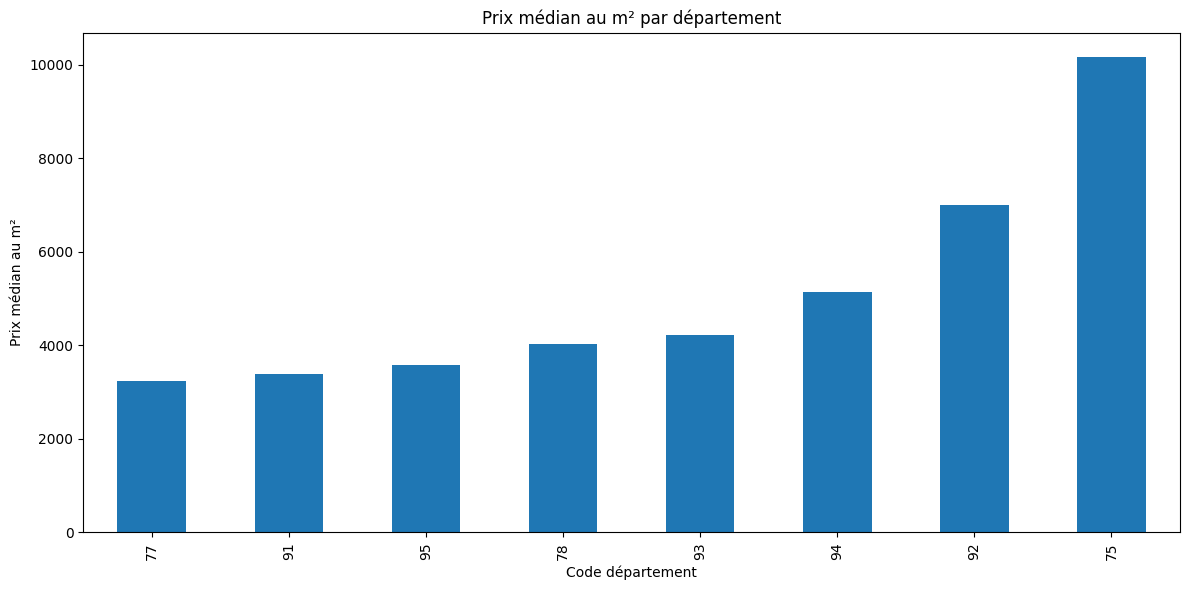

In [7]:
median_price_by_dept = train_df.groupby("code_departement")["prix_m2"].median().sort_values()
plt.figure(figsize=(12,6))
median_price_by_dept.plot(kind="bar")
plt.ylabel("Prix médian au m²")
plt.xlabel("Code département")
plt.title("Prix médian au m² par département")
plt.tight_layout()
plt.show()

### 2. Faire un modèle pour Paris et hors Paris

#### 2.1. Optimisation hyperparamètres sur un jeu de données réduit, entrainement et évaluation du modèle 

In [8]:
def objective(trial, X, y, sample_size=None, initial_params=None, model_cls=RandomForestRegressor):
    """Fonction objectif pour Optuna, compatible RF et XGBoost"""
    # Définir les plages de recherche autour des paramètres initiaux
    if model_cls.__name__ == "RandomForestRegressor":
        if initial_params is not None:
            params = {
                'n_estimators': trial.suggest_int(
                    'n_estimators', 
                    max(50, int(initial_params['n_estimators'] * 0.8)), 
                    min(300, int(initial_params['n_estimators'] * 1.2))
                ),
                'max_depth': trial.suggest_int(
                    'max_depth', 
                    max(5, initial_params['max_depth'] - 5), 
                    min(30, initial_params['max_depth'] + 5)
                ),
                'min_samples_split': trial.suggest_int(
                    'min_samples_split', 
                    max(2, initial_params['min_samples_split'] - 3), 
                    min(20, initial_params['min_samples_split'] + 3)
                ),
                'min_samples_leaf': trial.suggest_int(
                    'min_samples_leaf', 
                    max(1, initial_params['min_samples_leaf'] - 2), 
                    min(10, initial_params['min_samples_leaf'] + 2)
                ),
                'max_features': trial.suggest_float(
                    'max_features', 
                    max(0.1, initial_params['max_features'] - 0.2), 
                    min(1.0, initial_params['max_features'] + 0.2)
                ),
                'random_state': 42,
                'n_jobs': -1
            }
        else:
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 300),
                'max_depth': trial.suggest_int('max_depth', 5, 30),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                'max_features': trial.suggest_float('max_features', 0.1, 1.0),
                'random_state': 42,
                'n_jobs': -1
            }
    else:  # XGBoost
        if initial_params is not None:
            params = {
                'n_estimators': trial.suggest_int(
                    'n_estimators', 
                    max(100, int(initial_params['n_estimators'] * 0.8)), 
                    min(1500, int(initial_params['n_estimators'] * 1.2))
                ),
                'max_depth': trial.suggest_int(
                    'max_depth', 
                    max(3, initial_params['max_depth'] - 3), 
                    min(20, initial_params['max_depth'] + 3)
                ),
                'learning_rate': trial.suggest_float(
                    'learning_rate', 
                    max(0.001, initial_params['learning_rate'] * 0.8), 
                    min(0.3, initial_params['learning_rate'] * 1.2)
                ),
                'subsample': trial.suggest_float(
                    'subsample', 
                    max(0.5, initial_params['subsample'] - 0.2), 
                    min(1.0, initial_params['subsample'] + 0.2)
                ),
                'colsample_bytree': trial.suggest_float(
                    'colsample_bytree', 
                    max(0.3, initial_params['colsample_bytree'] - 0.2), 
                    min(1.0, initial_params['colsample_bytree'] + 0.2)
                ),
                'min_child_weight': trial.suggest_int(
                    'min_child_weight', 
                    max(1, initial_params['min_child_weight'] - 2), 
                    min(10, initial_params['min_child_weight'] + 2)
                ),
                'gamma': trial.suggest_float(
                    'gamma', 
                    max(0, initial_params['gamma'] - 2), 
                    initial_params['gamma'] + 2
                ),
                'reg_alpha': trial.suggest_float(
                    'reg_alpha', 
                    max(0, initial_params['reg_alpha'] * 0.8), 
                    initial_params['reg_alpha'] * 1.2
                ),
                'reg_lambda': trial.suggest_float(
                    'reg_lambda', 
                    max(0, initial_params['reg_lambda'] * 0.8), 
                    initial_params['reg_lambda'] * 1.2
                ),
                'random_state': 42,
                'n_jobs': -1
            }
        else:
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 1500),
                'max_depth': trial.suggest_int('max_depth', 3, 20),
                'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.3),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'gamma': trial.suggest_float('gamma', 0, 10),
                'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
                'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
                'random_state': 42,
                'n_jobs': -1
            }
    # Échantillonnage si demandé
    if sample_size is not None:
        n_samples = min(sample_size, len(X))
        np.random.seed(42) 
        indices = np.random.choice(len(X), size=n_samples, replace=False)
        X_sample = X.iloc[indices]
        y_sample = y.iloc[indices]
    else:
        X_sample = X
        y_sample = y

    model = model_cls(**params)
    scores = cross_val_score(model, X_sample, y_sample, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    return -scores.mean()

def optimize_and_train(X_train, y_train, zone_name, sample_size=None, n_trials=20, initial_params=None, model_cls=RandomForestRegressor):
    """Optimise les hyperparamètres et entraîne le modèle final (RF ou XGBoost)"""
    print(f"\n{'='*60}")
    print(f"Optimisation pour {zone_name}")
    if sample_size is not None:
        actual_size = min(sample_size, len(X_train))
        print(f"Utilisation de {actual_size} observations pour l'optimisation (sur {len(X_train)} disponibles)")
    else:
        print(f"Utilisation de toutes les données pour l'optimisation ({len(X_train)} observations)")
    if initial_params is not None:
        print("Recherche LOCALE autour des hyperparamètres initiaux")
        print(f"Paramètres de départ: {initial_params}")
    else:
        print("Recherche GLOBALE des hyperparamètres")
    print(f"{'='*60}")

    study = optuna.create_study(direction='minimize', study_name=f"{model_cls.__name__}_{zone_name}")
    if initial_params is not None:
        print("Évaluation des hyperparamètres de départ...")
        study.enqueue_trial(initial_params)
    print(f"Recherche des meilleurs hyperparamètres ({n_trials} trials)...")
    study.optimize(
        lambda trial: objective(trial, X_train, y_train, sample_size=sample_size, initial_params=initial_params, model_cls=model_cls), 
        n_trials=n_trials, 
        show_progress_bar=True
    )
    best_params = study.best_params
    best_params['random_state'] = 42
    best_params['n_jobs'] = -1

    print("\nMeilleurs hyperparamètres trouvés :")
    for param, value in best_params.items():
        if param not in ['random_state', 'n_jobs']:
            initial_val = initial_params.get(param, 'N/A') if initial_params else 'N/A'
            print(f"  {param}: {value} (initial: {initial_val})")
    print(f"\nMeilleur MAE en CV : {study.best_value:.4f}")

    print(f"\nEntraînement du modèle final sur {zone_name} (100% des données - {len(X_train)} observations)...")
    final_model = model_cls(**best_params)
    final_model.fit(X_train, y_train)
    print(f"Modèle sur {zone_name} entraîné.")

    return final_model, best_params, study.best_value

# Définir les hyperparamètres initiaux

# Xgboost best params trouvés précédemment
initial_params_xgboost = {'n_estimators': 775,
                          'max_depth': 12,
                          'learning_rate': 0.014782011673253295,   
                          'subsample': 0.9357174649094887,   
                          'colsample_bytree': 0.6147138328324339,   
                          'min_child_weight': 5,   
                          'gamma': 5.722492597986979,   
                          'reg_alpha': 0.05048493723008041,   
                          'reg_lambda': 2.3619571121802574}


# Random Forest initial params 
initial_params_rf_paris = {'n_estimators': 192, 
                     'max_depth': 20, 
                     'min_samples_split': 10, 
                     'min_samples_leaf': 4, 
                     'max_features': 0.24223906541740248}

initial_params_rf_hors_paris = {'n_estimators': 278, 
                                'max_depth': 17, 
                                'min_samples_split': 3, 
                                'min_samples_leaf': 1, 
                                'max_features': 0.35739984068330766}

In [9]:
# Paris (75)
X_train_paris = X_train[X_train["code_departement"] == "75"].drop(columns=["code_departement", "distance_paris"])
y_train_paris = y_train[X_train["code_departement"] == "75"]

# Hors Paris
X_train_hors_paris = X_train[X_train["code_departement"] != "75"].drop(columns=["code_departement"])
y_train_hors_paris = y_train[X_train["code_departement"] != "75"]

# Random Forest optimisation
model_paris_rf, params_paris_rf, score_paris_rf = optimize_and_train(
    X_train_paris, y_train_paris, "Paris (75) RF",
    sample_size=20000, n_trials=5, initial_params=initial_params_rf_paris, model_cls=RandomForestRegressor
)
model_hors_paris_rf, params_hors_paris_rf, score_hors_paris_rf = optimize_and_train(
    X_train_hors_paris, y_train_hors_paris, "Hors Paris RF",
    sample_size=20000, n_trials=5, initial_params=initial_params_rf_hors_paris, model_cls=RandomForestRegressor
)

# XGBoost optimisation
model_paris_xgb, params_paris_xgb, score_paris_xgb = optimize_and_train(
    X_train_paris, y_train_paris, "Paris (75) XGB",
    sample_size=20000, n_trials=5, initial_params=initial_params_xgboost, model_cls=XGBRegressor
)
model_hors_paris_xgb, params_hors_paris_xgb, score_hors_paris_xgb = optimize_and_train(
    X_train_hors_paris, y_train_hors_paris, "Hors Paris XGB",
    sample_size=20000, n_trials=5, initial_params=initial_params_xgboost, model_cls=XGBRegressor
)

# Résumé des résultats
print("RÉSUMÉ DES OPTIMISATIONS")
print(f"Paris (75) RF - MAE CV: {score_paris_rf:.4f}")
print(f"Hors Paris RF - MAE CV: {score_hors_paris_rf:.4f}")
print(f"Paris (75) XGB - MAE CV: {score_paris_xgb:.4f}")
print(f"Hors Paris XGB - MAE CV: {score_hors_paris_xgb:.4f}")

[I 2025-11-30 20:32:00,680] A new study created in memory with name: RandomForestRegressor_Paris (75) RF



Optimisation pour Paris (75) RF
Utilisation de 20000 observations pour l'optimisation (sur 97797 disponibles)
Recherche LOCALE autour des hyperparamètres initiaux
Paramètres de départ: {'n_estimators': 192, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.24223906541740248}
Évaluation des hyperparamètres de départ...
Recherche des meilleurs hyperparamètres (5 trials)...


Best trial: 0. Best value: 1531.13:  20%|██        | 1/5 [00:07<00:30,  7.64s/it]

[I 2025-11-30 20:32:08,320] Trial 0 finished with value: 1531.1333755568105 and parameters: {'n_estimators': 192, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.24223906541740248}. Best is trial 0 with value: 1531.1333755568105.


Best trial: 1. Best value: 1530.81:  40%|████      | 2/5 [00:12<00:18,  6.14s/it]

...

[I 2025-11-30 20:38:56,201] Trial 2 finished with value: 918.9698486328125 and parameters: {'n_estimators': 834, 'max_depth': 14, 'learning_rate': 0.01579560466628536, 'subsample': 0.7800916606669758, 'colsample_bytree': 0.46086289805367847, 'min_child_weight': 3, 'gamma': 4.350517063738519, 'reg_alpha': 0.05127396037813204, 'reg_lambda': 2.684498708547868}. Best is trial 0 with value: 909.5236083984375.


Best trial: 0. Best value: 909.524:  80%|████████  | 4/5 [02:43<00:41, 41.10s/it]

[I 2025-11-30 20:39:25,991] Trial 3 finished with value: 910.1406127929688 and parameters: {'n_estimators': 821, 'max_depth': 11, 'learning_rate': 0.014284049041312407, 'subsample': 0.8058804520975229, 'colsample_bytree': 0.7480245357552293, 'min_child_weight': 6, 'gamma': 7.577075310872591, 'reg_alpha': 0.057696071715627975, 'reg_lambda': 2.4161635535839276}. Best is trial 0 with value: 909.5236083984375.


Best trial: 0. Best value: 909.524: 100%|██████████| 5/5 [03:20<00:00, 40.19s/it]


[I 2025-11-30 20:40:03,443] Trial 4 finished with value: 914.8049072265625 and parameters: {'n_estimators': 912, 'max_depth': 11, 'learning_rate': 0.015255335717696626, 'subsample': 0.9647320029091502, 'colsample_bytree': 0.7997684363434484, 'min_child_weight': 4, 'gamma': 3.9412495119604856, 'reg_alpha': 0.043115207553763524, 'reg_lambda': 1.9875442420796599}. Best is trial 0 with value: 909.5236083984375.

Meilleurs hyperparamètres trouvés :
  n_estimators: 775 (initial: 775)
  max_depth: 12 (initial: 12)
  learning_rate: 0.014782011673253295 (initial: 0.014782011673253295)
  subsample: 0.9357174649094887 (initial: 0.9357174649094887)
  colsample_bytree: 0.6147138328324339 (initial: 0.6147138328324339)
  min_child_weight: 5 (initial: 5)
  gamma: 5.722492597986979 (initial: 5.722492597986979)
  reg_alpha: 0.05048493723008041 (initial: 0.05048493723008041)
  reg_lambda: 2.3619571121802574 (initial: 2.3619571121802574)

Meilleur MAE en CV : 909.5236

Entraînement du modèle final sur Hor

In [10]:
print("Best hyperparameters found for each train:")

print("\nParis RF:")
print(params_paris_rf)

print("\nHors Paris RF:")
print(params_hors_paris_rf)

print("\nParis XGB:")
print(params_paris_xgb)

print("\nHors Paris XGB:")
print(params_hors_paris_xgb)

Best hyperparameters found for each train:

Paris RF:
{'n_estimators': 157, 'max_depth': 17, 'min_samples_split': 13, 'min_samples_leaf': 2, 'max_features': 0.14821034087378557, 'random_state': 42, 'n_jobs': -1}

Hors Paris RF:
{'n_estimators': 278, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 0.35739984068330766, 'random_state': 42, 'n_jobs': -1}

Paris XGB:
{'n_estimators': 631, 'max_depth': 11, 'learning_rate': 0.016592280011187954, 'subsample': 0.9513284186556717, 'colsample_bytree': 0.44478565241982193, 'min_child_weight': 5, 'gamma': 7.199648105311235, 'reg_alpha': 0.04842296708370371, 'reg_lambda': 2.394895125497978, 'random_state': 42, 'n_jobs': -1}

Hors Paris XGB:
{'n_estimators': 775, 'max_depth': 12, 'learning_rate': 0.014782011673253295, 'subsample': 0.9357174649094887, 'colsample_bytree': 0.6147138328324339, 'min_child_weight': 5, 'gamma': 5.722492597986979, 'reg_alpha': 0.05048493723008041, 'reg_lambda': 2.3619571121802574, 'random_stat

Le XgBoost a de légères meilleures performances. On va donc utiliser ce modèle. 

In [14]:
# Prédiction XGBoost selon Paris ou hors Paris
def predict_xgb_by_zone(df, model_paris, model_hors_paris):
    preds = pd.Series(index=df.index, dtype="float32")
    paris_mask = df["code_departement"] == "75"
    hors_paris_mask = df["code_departement"] != "75"

    # Paris
    if paris_mask.any():
        X_paris = df[paris_mask].drop(columns=["code_departement", "distance_paris"], errors="ignore")
        preds.loc[paris_mask] = model_paris.predict(X_paris)
    # Hors Paris
    if hors_paris_mask.any():
        X_hors_paris = df[hors_paris_mask].drop(columns=["code_departement"], errors="ignore")
        preds.loc[hors_paris_mask] = model_hors_paris.predict(X_hors_paris)
    return preds

# Prédictions sur train, test et oos
y_pred_train_xgb = predict_xgb_by_zone(X_train, model_paris_xgb, model_hors_paris_xgb)
y_pred_test_xgb = predict_xgb_by_zone(X_test, model_paris_xgb, model_hors_paris_xgb)
y_pred_oos_xgb = predict_xgb_by_zone(X_oos, model_paris_xgb, model_hors_paris_xgb)

In [15]:
# MAE sur Paris et hors Paris pour le train set
mae_train_paris = mean_absolute_error(
    y_train[X_train["code_departement"] == "75"],
    y_pred_train_xgb[X_train["code_departement"] == "75"]
)
mae_train_hors_paris = mean_absolute_error(
    y_train[X_train["code_departement"] != "75"],
    y_pred_train_xgb[X_train["code_departement"] != "75"]
)

# MAE sur Paris et hors Paris pour le test set
mae_test_paris = mean_absolute_error(
    y_test[test_df["code_departement"] == "75"],
    y_pred_test_xgb[test_df["code_departement"] == "75"]
)
mae_test_hors_paris = mean_absolute_error(
    y_test[test_df["code_departement"] != "75"],
    y_pred_test_xgb[test_df["code_departement"] != "75"]
)

# MAE sur Paris et hors Paris pour le out-of-sample set
mae_oos_paris = mean_absolute_error(
    y_oos[oos_df["code_departement"] == "75"],
    y_pred_oos_xgb[oos_df["code_departement"] == "75"]
)
mae_oos_hors_paris = mean_absolute_error(
    y_oos[oos_df["code_departement"] != "75"],
    y_pred_oos_xgb[oos_df["code_departement"] != "75"]
)

print(f"MAE train Paris: {mae_train_paris:.2f}")
print(f"MAE train hors Paris: {mae_train_hors_paris:.2f}")
print(f"MAE test Paris: {mae_test_paris:.2f}")
print(f"MAE test hors Paris: {mae_test_hors_paris:.2f}")
print(f"MAE oos Paris: {mae_oos_paris:.2f}")
print(f"MAE oos hors Paris: {mae_oos_hors_paris:.2f}")

MAE train Paris: 1187.71
MAE train hors Paris: 624.30
MAE test Paris: 1491.97
MAE test hors Paris: 781.90
MAE oos Paris: 1241.60
MAE oos hors Paris: 663.62


In [ ]:
mae_train = mean_absolute_error(y_train, y_pred_train_xgb)
mae_test = mean_absolute_error(y_test, y_pred_test_xgb)
mae_oos = mean_absolute_error(y_oos, y_pred_oos_xgb)

print(f"MAE train: {mae_train:.2f}")
print(f"MAE test: {mae_test:.2f}")
print(f"MAE oos: {mae_oos:.2f}")

MAE train: 732.89
MAE test: 919.04
MAE oos: 784.00


#### 2.2 Entrainement Xgboost avec les hyperparamètres initiaux (trouvés à partir d'une recherche d'hyperparamètres sur toute la base dans un autre notebook)

In [17]:
# Entrainement sur Paris
model_paris_xgb_custom = XGBRegressor(**initial_params_xgboost)
model_paris_xgb_custom.fit(X_train_paris, y_train_paris)

# Entraînement sur hors Paris
model_hors_paris_xgb_custom = XGBRegressor(**initial_params_xgboost)
model_hors_paris_xgb_custom.fit(X_train_hors_paris, y_train_hors_paris)

# Prédictions sur train, test et oos
y_pred_train_xgb = predict_xgb_by_zone(X_train, model_paris_xgb_custom, model_hors_paris_xgb_custom)
y_pred_test_xgb = predict_xgb_by_zone(X_test, model_paris_xgb_custom, model_hors_paris_xgb_custom)
y_pred_oos_xgb = predict_xgb_by_zone(X_oos, model_paris_xgb_custom, model_hors_paris_xgb_custom)

In [18]:
# MAE sur Paris et hors Paris pour le train set
mae_train_paris = mean_absolute_error(
    y_train[X_train["code_departement"] == "75"],
    y_pred_train_xgb[X_train["code_departement"] == "75"]
)
mae_train_hors_paris = mean_absolute_error(
    y_train[X_train["code_departement"] != "75"],
    y_pred_train_xgb[X_train["code_departement"] != "75"]
)

# MAE sur Paris et hors Paris pour le test set
mae_test_paris = mean_absolute_error(
    y_test[test_df["code_departement"] == "75"],
    y_pred_test_xgb[test_df["code_departement"] == "75"]
)
mae_test_hors_paris = mean_absolute_error(
    y_test[test_df["code_departement"] != "75"],
    y_pred_test_xgb[test_df["code_departement"] != "75"]
)

# MAE sur Paris et hors Paris pour le out-of-sample set
mae_oos_paris = mean_absolute_error(
    y_oos[oos_df["code_departement"] == "75"],
    y_pred_oos_xgb[oos_df["code_departement"] == "75"]
)
mae_oos_hors_paris = mean_absolute_error(
    y_oos[oos_df["code_departement"] != "75"],
    y_pred_oos_xgb[oos_df["code_departement"] != "75"]
)

print(f"MAE train Paris: {mae_train_paris:.2f}")
print(f"MAE train hors Paris: {mae_train_hors_paris:.2f}")
print(f"MAE test Paris: {mae_test_paris:.2f}")
print(f"MAE test hors Paris: {mae_test_hors_paris:.2f}")
print(f"MAE oos Paris: {mae_oos_paris:.2f}")
print(f"MAE oos hors Paris: {mae_oos_hors_paris:.2f}")

MAE train Paris: 1054.31
MAE train hors Paris: 624.97
MAE test Paris: 1492.00
MAE test hors Paris: 781.98
MAE oos Paris: 1133.55
MAE oos hors Paris: 662.98


In [19]:
mae_train = mean_absolute_error(y_train, y_pred_train_xgb)
mae_test = mean_absolute_error(y_test, y_pred_test_xgb)
mae_oos = mean_absolute_error(y_oos, y_pred_oos_xgb)

print(f"MAE train: {mae_train:.2f}")
print(f"MAE test: {mae_test:.2f}")
print(f"MAE oos: {mae_oos:.2f}")

MAE train: 707.73
MAE test: 919.10
MAE oos: 760.99


### 3. Interpréter les performances du modèle et comprendre ses limites 

#### 3.1 Comparer nos performances à un modèle naif 

Sur le test :

In [ ]:
# Calcul de la MAE du modèle naïf (médiane)
mediane_prix_m2 = np.median(y_test[X_test["code_departement"] == "75"])
y_naif = np.repeat(mediane_prix_m2, len(y_test[X_test["code_departement"] == "75"]))
mae_naif = mean_absolute_error(y_test[X_test["code_departement"] == "75"], y_naif)

# Amélioration relative
amelioration = (mae_naif - mean_absolute_error(y_test, y_pred_test_xgb)) / mae_naif * 100

print(f"MAE du modèle naïf (médiane) : {mae_naif:.0f} €/m²")
print(f"MAE de ton modèle : {mean_absolute_error(y_test, y_pred_test_xgb):.0f} €/m²")
print(f"Amélioration relative : {amelioration:.1f}%")

MAE du modèle naïf (médiane) : 1850 €/m²
MAE de ton modèle : 919 €/m²
Amélioration relative : 50.3%


Sur l'out of sample (2025) :

In [21]:
# Calcul de la MAE du modèle naïf (médiane)
mediane_prix_m2 = np.median(y_oos[X_oos["code_departement"] == "75"])
y_naif = np.repeat(mediane_prix_m2, len(y_oos[X_oos["code_departement"] == "75"]))
mae_naif = mean_absolute_error(y_oos[X_oos["code_departement"] == "75"], y_naif)

# Amélioration relative
amelioration = (mae_naif - mean_absolute_error(y_oos, y_pred_oos_xgb)) / mae_naif * 100

print(f"MAE du modèle naïf (médiane) : {mae_naif:.0f} €/m²")
print(f"MAE de ton modèle : {mean_absolute_error(y_oos, y_pred_oos_xgb):.0f} €/m²")
print(f"Amélioration relative : {amelioration:.1f}%")

MAE du modèle naïf (médiane) : 1864 €/m²
MAE de ton modèle : 761 €/m²
Amélioration relative : 59.2%


Notre modèle fait entre 50 et 60% mieux qu'une prédiction naive. 

#### 3.2 Identifier les observations avec les erreurs les plus fortes (top 10%)


Sur le test :

In [ ]:
df_test = test_df.copy()
df_test["pred_prix_m2"] = y_pred_test_xgb.values

# Calcul des erreurs absolues
df_test["erreur_absolue"] = abs(df_test["prix_m2"] - df_test["pred_prix_m2"])

# Seuil pour le top 10% des erreurs
seuil = df_test["erreur_absolue"].quantile(0.9)

# Extraction des observations problématiques
top_10_erreurs = df_test[df_test["erreur_absolue"] >= seuil]

# Tri par erreur décroissante
top_10_erreurs = top_10_erreurs.sort_values("erreur_absolue", ascending=False)

# Affichage des résultats
print(f"Seuil pour le top 10% des erreurs : {seuil:.0f} €/m²")
print(f"Nombre d'observations dans le top 10% : {len(top_10_erreurs)}")

# Afficher les 10 pires prédictions 
cols_to_show = ["prix_m2", "pred_prix_m2", "erreur_absolue", "code_departement"]
top_10_erreurs[cols_to_show]

Seuil pour le top 10% des erreurs : 2164 €/m²
Nombre d'observations dans le top 10% : 12685


,prix_m2,pred_prix_m2,erreur_absolue,code_departement
59622,15000.000000,3266.318604,11733.681641,77
14235,14119.047852,2667.129883,11451.917969,77
18288,15000.000000,3578.007324,11421.992188,93
58905,14750.000000,3541.983643,11208.016602,77
66522,14826.446289,3776.993652,11049.453125,91
...,...,...,...,...
7254,7518.518555,9682.363281,2163.844727,75
114753,10000.000000,12163.818359,2163.818359,75
70960,3961.428467,6125.243652,2163.815186,92
83427,9277.777344,11441.421875,2163.644531,75


In [25]:
top_10_erreurs["code_departement"].value_counts()

code_departement
75    5543
92    2139
94    1227
78    1064
93    1023
77     650
95     525
91     514
Name: count, dtype: int64

Comme attendu on fait beaucoup d'erreurs sur Paris. Il y a beaucoup de valeurs aberrantes. 

Le modèle est moins performant sur sur les valeurs extremes (ce qui découle aussi du choix de la métrique):

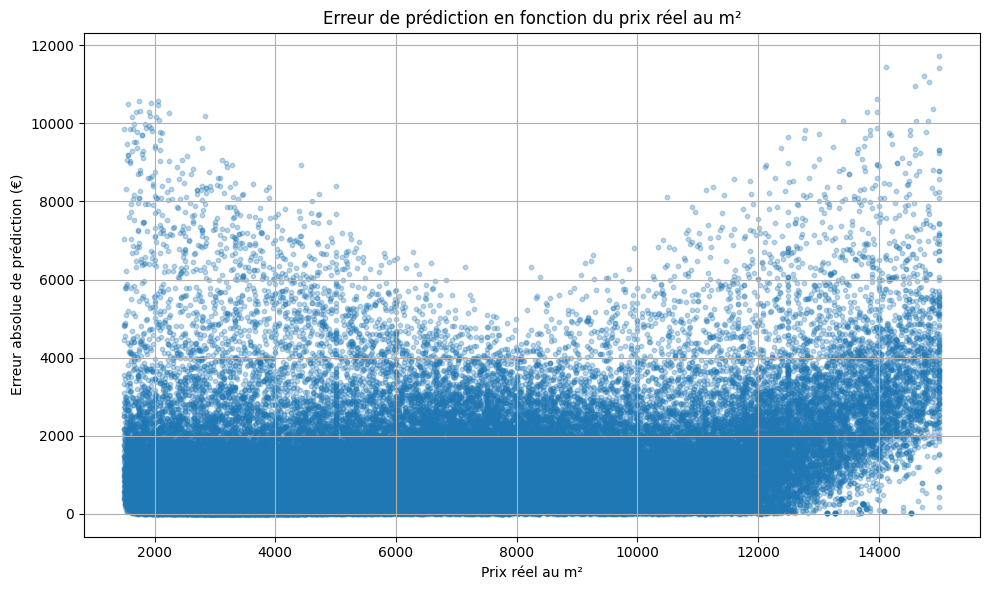

In [23]:
plt.figure(figsize=(10,6))
plt.scatter(df_test["prix_m2"], df_test["erreur_absolue"], alpha=0.3, s=10)
plt.xlabel("Prix réel au m²")
plt.ylabel("Erreur absolue de prédiction (€)")
plt.title("Erreur de prédiction en fonction du prix réel au m²")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# Découper le prix réel en tranches de 1000€
df_test["prix_m2_bin"] = (df_test["prix_m2"] // 1000) * 1000

# Calculer l'erreur absolue moyenne par tranche de prix
erreur_moyenne_par_bin = df_test.groupby("prix_m2_bin")["erreur_absolue"].mean()

# Ajouter la population (nombre d'observations) par tranche de prix au DataFrame
erreur_moyenne_par_bin = erreur_moyenne_par_bin.to_frame("erreur_absolue_moyenne")
erreur_moyenne_par_bin["population"] = df_test.groupby("prix_m2_bin").size()

# Calculer la proportion de la population pour chaque bin
total_population = erreur_moyenne_par_bin["population"].sum()
erreur_moyenne_par_bin["proportion_population"] = (erreur_moyenne_par_bin["population"] / total_population) * 100
erreur_moyenne_par_bin = erreur_moyenne_par_bin.round(4)

erreur_moyenne_par_bin

,erreur_absolue_moyenne,population,proportion_population
prix_m2_bin,,,
1000.0,1069.018799,4070,3.2086
2000.0,625.700806,19398,15.2923
3000.0,537.394409,25637,20.2108
4000.0,697.884399,17455,13.7606
5000.0,900.348511,11745,9.2591
6000.0,1009.672913,9029,7.1180
7000.0,1099.666748,7674,6.0498
8000.0,1107.976440,7359,5.8014
9000.0,1021.390381,6516,5.1369


Le modèle est performant sur la tranche de prix 2000e - 5000e (là où se concentrent une grande partie des ventes), est moyennement performant sur les ventes dont le prix au mètre carré est inférieur à 10 000e mais a des difficulté claires sur les ventes au prix extrêmes. 

#### 3.3 Principales limites identifiées de notre modèle 

La qualité des données semblent limitée malgré nos filtres. On observe des ventes à des prix dérisoires parfois. 
Nous n'avons pas assez de variables expliquant les caractéristiques de la vente (typologie du bien, surface carrez, etat du bien, année de construction du bien, standing du bien, exposition, ect.)